<a href="https://colab.research.google.com/github/jagadeeshsandopu/CNN-using-PyTorch/blob/main/CNN_using_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.datasets.utils import download_url
from torch.utils.data import random_split,DataLoader
import tarfile
import matplotlib.pyplot as plt

In [ ]:
import os

filename = "cifar-10-batches-py"
if os.path.exists(filename):
    os.remove(filename)
    print(f"Removed corrupted file: {filename}")

In [ ]:
dataset_url = "https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz"
download_url(dataset_url,'.')

In [ ]:
with tarfile.open('./cifar10.tgz','r:gz') as tar:
  tar.extractall(path = './data')


/tmp/ipykernel_6015/4081173683.py:2: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path = './data')


In [ ]:

train_transformations = transforms.Compose([
    transforms.RandomCrop(32,padding = 4, padding_mode = "reflect"),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToTensor()
    # transforms.Normalize(mean = (0.4914,0.4822,0.4465),
    #                      std  = (0.2023,0.1994,0.2010),
    #                      inplace = True)
])

validation_transformations = transforms.Compose([
    transforms.ToTensor()
    # transforms.Normalize(mean = (0.4914,0.4822,0.4465),
    #                      std  = (0.2023,0.1994,0.2010))
])

In [ ]:
datadir = "data/cifar10"

In [ ]:
train_ds = ImageFolder(datadir+'/train',transform = train_transformations)
test_ds = ImageFolder(datadir+'/test',transform = validation_transformations)

len(train_ds),len(test_ds)

(50000, 10000)

In [ ]:
classes = train_ds.classes
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
val_size = 5000
train_size = len(train_ds)-val_size

train_ds,val_ds = random_split(train_ds,[train_size,val_size])

In [ ]:
batch_size = 128

train_dl = DataLoader(train_ds,batch_size = batch_size,num_workers=2,shuffle = True,pin_memory = True)
val_dl = DataLoader(val_ds,batch_size = batch_size , shuffle = False,pin_memory = True)

In [ ]:
for batch in train_dl:
  print(batch[0].shape)
  print(batch[1])
  break

torch.Size([128, 3, 32, 32])
tensor([6, 9, 6, 9, 8, 0, 0, 2, 6, 7, 3, 8, 9, 1, 8, 1, 2, 4, 9, 5, 2, 2, 7, 2,
        0, 5, 0, 8, 3, 5, 4, 7, 9, 3, 6, 9, 3, 0, 8, 2, 0, 4, 4, 0, 5, 2, 5, 1,
        3, 4, 3, 8, 4, 5, 2, 0, 1, 2, 3, 5, 1, 1, 1, 9, 7, 6, 1, 9, 4, 5, 4, 3,
        5, 1, 0, 6, 8, 2, 1, 4, 2, 9, 5, 8, 0, 1, 6, 3, 3, 1, 0, 9, 7, 0, 4, 7,
        4, 3, 4, 8, 9, 0, 5, 5, 2, 8, 0, 4, 7, 9, 9, 3, 6, 9, 8, 8, 4, 4, 6, 0,
        4, 3, 7, 5, 5, 6, 8, 1])


torch.Size([3, 32, 32])
8


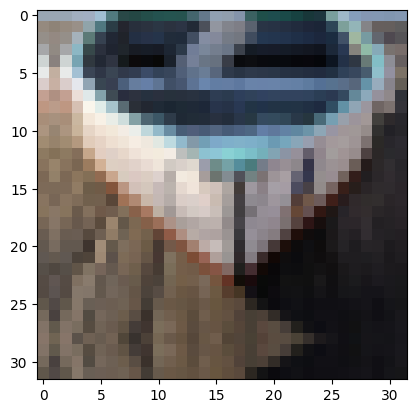

In [ ]:
img,label = train_ds[10]

print(img.shape)
print(label)
plt.imshow(img.permute((1,2,0)))

# Training and Evaluation

In [ ]:
@torch.no_grad()
def evaluate(model,validation_dl):
   model.eval()
   outputs = [model.validation_step(batch) for batch in validation_dl]
   return model.validation_epoch_end(outputs)

##################################################################################################################

def get_learning_rate(optimizer):

  for param_group in optimizer.param_groups:
    return param_group['lr']

##################################################################################################################

def training_cycle(model,epochs,max_lr,train_dl,val_dl,grad_clip,weight_decay,optimizer_type = torch.optim.Adam):

  history = []
  optimizer = optimizer_type(model.parameters(),max_lr, weight_decay = weight_decay)
  sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs = epochs, steps_per_epoch = len(train_dl))

  for epoch in range(epochs):

    # Training Phase

    model.train()
    training_losses = []
    lrs = []


    for batch in train_dl:

      loss = model.training_step(batch)
      training_losses.append(loss.item())
      optimizer.zero_grad()
      loss.backward()

      if grad_clip:
        nn.utils.clip_grad_value_(model.parameters(),grad_clip)

      lrs.append(get_learning_rate(optimizer))
      optimizer.step()
      sched.step()

    # Validation Phase

    result = evaluate(model,val_dl)
    result['train_losses'] = sum(training_losses) / len(training_losses)
    result['lrs'] = lrs
    model.epoch_end(epoch,result)
    history.append(result)

  return history


def accuracy(predictions,labels):
  _, preds = torch.max(predictions,dim=1)
  return (torch.sum(preds == labels)/len(labels)).item()

# Base Model

In [ ]:
class ImageClassificationBaseModel(nn.Module):

  def training_step(self,batch):
    images,labels = batch
    outputs = self(images)
    loss = F.cross_entropy(outputs,labels)
    return loss


  def validation_step(self,batch):
    images,labels = batch
    outputs = self(images)
    loss = F.cross_entropy(outputs,labels).item()
    acc = accuracy(outputs,labels)
    return {'validation_loss':loss,'validation_accuracy':acc}


  def validation_epoch_end(self,outputs):
    validation_losses = [torch.tensor(x['validation_loss']) for x in outputs]
    validation_accuracies = [torch.tensor(x['validation_accuracy']) for x in outputs]
    mean_loss = torch.stack(validation_losses).mean().item()
    mean_accuracy = torch.stack(validation_accuracies).mean().item()
    return {'val_loss':mean_loss,'val_accuracy':mean_accuracy}


  def epoch_end(self,epoch,result):
    print(" Epoch: {} ------- Validation Loss: {} --------- Validation Accuracy: {} ----------- Training Loss: {}".format(epoch,result['val_loss'],round(result['val_accuracy']*100,1),result['train_losses']))

# ResNet9 Model Implementation

In [ ]:
from torch.nn.modules.activation import Softmax
from torch.nn.modules.pooling import MaxPool2d

In [ ]:
def conv_block(input_channels,output_channels,max_pool = False):

  layers = [nn.Conv2d(input_channels,output_channels,kernel_size = 3, stride = 1,padding = 1),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace = True)
            ]

  if max_pool == True:
    layers.append(nn.MaxPool2d(2,2))

  return nn.Sequential(*layers)

################################################################################################


class ResNet9(ImageClassificationBaseModel):

  def __init__(self,input_channels,num_classes):
    super().__init__()

    self.layer_1 = conv_block(input_channels,64,False)                  # 64 x 32 x 32
    self.layer_2 = conv_block(64,128,True)                              # 128 x 16 x 16
    self.res_1 = nn.Sequential(conv_block(128,128),conv_block(128,128)) # 128 x 16 x 16
    self.layer_3 = conv_block(128,256,True)                             # 256 x 8 x 8
    self.layer_4 = conv_block(256,512,True)                             # 512 x 4 x 4
    self.res_2 = nn.Sequential(conv_block(512,512),conv_block(512,512)) # 512 x 4 x 4

    self.classifier = nn.Sequential(
        nn.MaxPool2d(4,4),  # 512 x 1 x 1
        nn.Flatten(),
        nn.Dropout(p = 0.2),
        nn.Linear(512,num_classes)
    )


  def forward(self,input):

    out1 = self.layer_1(input)
    out2 = self.layer_2(out1)
    out3 = self.res_1(out2) + out2
    out4 = self.layer_3(out3)
    out5 = self.layer_4(out4)
    out6 = self.res_2(out5) + out5
    final_output = self.classifier(out6)

    return final_output


In [ ]:

class CIFAR10_Model(ImageClassificationBaseModel):

  def __init__(self):
    super().__init__()
    self.network = nn.Sequential(

    nn.Conv2d(3,32,kernel_size = 3,stride = 1,padding = 1),
    nn.ReLU(), # 32 x 32 x 32
    nn.Conv2d(32,64,kernel_size = 3,stride = 1, padding = 1),
    nn.ReLU(), # 64 x 32 x 32
    nn.MaxPool2d(2,2), # 64 x 16 x 16


    nn.Conv2d(64,128,kernel_size = 3,stride = 1,padding = 1),
    nn.ReLU(), # 128  x 16 x 16
    nn.Conv2d(128,128,kernel_size = 3,stride = 1, padding = 1),
    nn.ReLU(), # 128 x 16 x 16
    nn.MaxPool2d(2,2),  # 128 x 8 x 8


    nn.Conv2d(128,256,kernel_size = 3,stride = 1,padding = 1),
    nn.ReLU(), # 256  x 8 x 8
    nn.Conv2d(256,256,kernel_size = 3,stride = 1, padding = 1),
    nn.ReLU(), # 256 x 8 x 8
    nn.MaxPool2d(2,2),  # 256 x 4 x 4

    nn.Flatten(),
    nn.Linear(256*4*4,1024),
    nn.ReLU(),
    nn.Linear(1024,512),
    nn.ReLU(),
    nn.Linear(512,10)

    )


  def forward(self,input_images):
    return self.network(input_images)

In [ ]:
def get_default_device():

  if torch.cuda.is_available():
    return torch.device('cuda')
  else:
    return torch.device('cpu')

device = get_default_device()
print(device)

cuda


In [ ]:
def to_device(data,device):

  if isinstance(data,(list,tuple)):
    return [to_device(x,device) for x in data]
  else:
    return data.to(device,non_blocking = True)

In [ ]:
class DeviceDataLoader():

  def __init__(self,dl,device):
    self.dl = dl
    self.device = device

  def __iter__(self):
    for batch in self.dl:
      yield to_device(batch,device)

  def __len__(self):
    return len(self.dl)

In [ ]:
max_lr = 0.01
epochs = 10
grad_clip = 0.1
weight_decay = 1e-4

In [ ]:
%%time

model = ResNet9(3,10)

train_dl = DeviceDataLoader(train_dl,device)
val_dl = DeviceDataLoader(val_dl,device)
model = to_device(model,device)

hist = training_cycle(model,epochs,max_lr,train_dl,val_dl,grad_clip,weight_decay)

 Epoch: 0 ------- Validation Loss: 2.8874189853668213 --------- Validation Accuracy: 31.7 ----------- Training Loss: 1.4743636601011862
 Epoch: 1 ------- Validation Loss: 1.3180397748947144 --------- Validation Accuracy: 55.9 ----------- Training Loss: 1.0881237164139748
 Epoch: 2 ------- Validation Loss: 1.2801387310028076 --------- Validation Accuracy: 59.6 ----------- Training Loss: 0.8713357760147615
 Epoch: 3 ------- Validation Loss: 0.8381649851799011 --------- Validation Accuracy: 71.5 ----------- Training Loss: 0.6957805580036207
 Epoch: 4 ------- Validation Loss: 0.7667065858840942 --------- Validation Accuracy: 73.0 ----------- Training Loss: 0.6215930005366151
 Epoch: 5 ------- Validation Loss: 0.6026827096939087 --------- Validation Accuracy: 78.8 ----------- Training Loss: 0.5624597515402869
 Epoch: 6 ------- Validation Loss: 0.49322396516799927 --------- Validation Accuracy: 84.1 ----------- Training Loss: 0.4816097587516362
 Epoch: 7 ------- Validation Loss: 0.3969020247

# Testing

Text(0.5, 1.0, 'Validation Accuracy vs No of epochs')

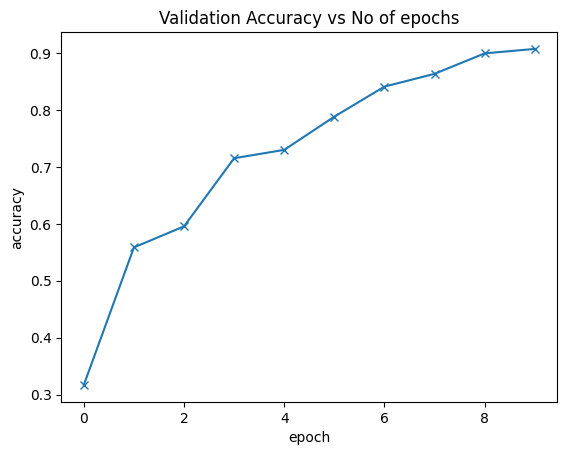

In [ ]:
accuracies = [x['val_accuracy'] for x in hist]
plt.plot(accuracies,'-x')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Validation Accuracy vs No of epochs')

Text(0.5, 1.0, 'Loss vs # of epochs')

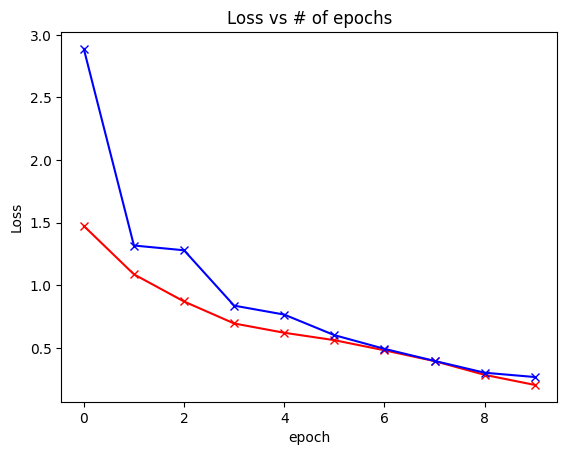

In [ ]:
train_losses = [x['train_losses'] for x in hist]
val_losses = [x['val_loss'] for x in hist]
plt.plot(train_losses,'-xr')
plt.plot(val_losses,'-xb')
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.title('Loss vs # of epochs')

torch.Size([3, 32, 32])
Prediction: ship --------- Actual: ship -------- Confidence: 100.0  





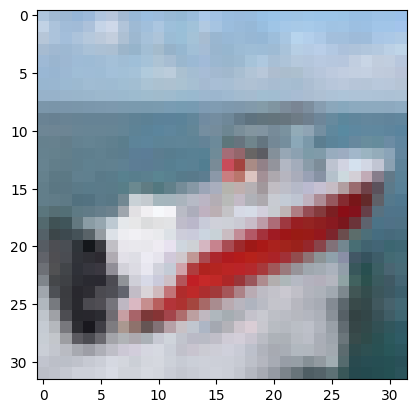

In [ ]:
def get_prediction(model,image):

  model = to_device(model,torch.device('cuda'))
  reshaped_img = image.reshape(1,3,32,32)
  image = to_device(reshaped_img,device)
  output = torch.softmax(model(image),dim = 1)
  confidence,pred = torch.max(output,dim = 1)
  return (pred.item(),confidence)



index = torch.randint(low=0,high=len(test_ds),size = (1,))
img,label = test_ds[index.item()]
print(img.shape)

prediction,confidence = get_prediction(model,img)

plt.imshow(img.permute((1,2,0)))
print("Prediction: {} --------- Actual: {} -------- Confidence: {}  \n\n\n".format(classes[prediction],classes[label],round(confidence.item()*100,2)))


In [ ]:
def get_accuracy(model,dataset):

  model = to_device(model,torch.device('cpu'))
  correct_count = 0
  conf = 0

  for img,label in dataset:
    res = F.softmax(model(img.reshape(1,3,32,32)),dim = 1)
    confidence,prediction = torch.max(res,dim = 1)

    if prediction == label:
      correct_count+=1
      conf+= confidence.item()

  return (round(conf*100/correct_count,2),round(correct_count*100/len(dataset),2))

In [ ]:
res = get_accuracy(model,test_ds)

In [ ]:
print("Test Accuracy: {}% ---------------------------- Avg Confidency: {}%".format(res[1],res[0]))

Test Accuracy: 90.62% ---------------------------- Avg Confidency: 94.83%
